In [1]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,)

import torchode

seed = 1234
set_global_seed(seed)

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
## Define system 
gamma = 50
def sigmoid(x,gamma=gamma):
    return 1 / (1+np.exp(-gamma*x))

eps = 0.02
q1, q2 = (0.08, 0.04)
b1 = 1-eps
b2 = 1-eps

def c1_in(x):
    return q1*(1-sigmoid(x-b1))

def c2_in(y):
    return q1*(1-sigmoid(y-b2))

def c1_out(y):
    return q2*(1-sigmoid(y-b2))

def c2_out(y):
    return q2

def two_tank_system(t,x,u):
    x1, x2 = x
    p, v = u
    x1= np.maximum(x1,0)
    x2 = np.maximum(x2,0)
    dx1dt = c1_in(x1)*(1-v)*p-c1_out(x2)*np.sqrt(x1)
    dx2dt = c2_in(x2)*v*p +c1_out(x2)*np.sqrt(x1)-q2*np.sqrt(x2)
    return np.hstack([dx1dt,dx2dt])


p_vals = np.linspace(0,1,101)
v_vals = np.linspace(0,1,101)

In [3]:
t_max = 200
n_colloc = 501

x0s = np.linspace(0,1,21)

In [4]:
p_train = p_vals[10:-10:10]
v_train = v_vals[10:-10:10]

In [5]:
Xs = [] 
Us = []
t = np.linspace(0,t_max, n_colloc)
for pi in tqdm(p_train):
    for vi in v_train:
        
        for x0 in zip(x0s, x0s):
            u = np.array([pi,vi])

            sol = sp_solve_ivp(
                two_tank_system,
                t_span = [0,t_max],
                y0 = np.array(x0),
                t_eval= np.linspace(0,t_max, n_colloc),
                args =(u,)
            )

            Xs.append(sol.y.T)
            Us.append((pi,vi))

Us = np.array(Us)
Xs = np.array(Xs)

  0%|          | 0/9 [00:00<?, ?it/s]

In [6]:
dXs = np.zeros_like(Xs)
T = t[np.newaxis,:,np.newaxis]
X_diff = Xs[:,2:,:] - Xs[:,:-2,:]
T_diff = T[:,2:,:] - T[:,:-2,:]

dXs[:,1:-1,:] = X_diff/T_diff
dXs[:,0,:] = (Xs[:,1,:] - Xs[:,0,:]) / (T[:,1,:] - T[:,0,:])
dXs[:,-1,:] = (Xs[:,-1,:] - Xs[:,-2,:]) / (T[:,-1,:] - T[:,-2,:])

In [7]:
dX_tensor = [
    torch.tensor(dxi,dtype=torch.float32,device=device) for dxi in dXs
]
X_tensor = [
    torch.tensor(xi,dtype=torch.float32,device=device) for xi in Xs
]
U_tensor = [
    torch.tensor(ui,dtype=torch.float32,device=device) for ui in Us
]

T_tensor = [
    torch.tensor(t,dtype=torch.float32, device=device) for _ in range(len(Xs))
]

In [8]:
class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U
        # self.trans_idx = Transient_idx

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(
                f"Index {idx} is out of bounds of dataset size: {len(self)}."
            )

        dXi = self.dX[idx]
        Xi = self.X[idx]
        ti = self.T[idx]
        ui = self.U[idx]

        return dXi, Xi, ti, ui

dataset = GradDataset(dX = dX_tensor,X = X_tensor, T = T_tensor, U = U_tensor)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=50, shuffle=True)

# Train Model

In [9]:
import torch
import torch.nn as nn
import time
import copy  # Added to deepcopy weights in memory


f = FeluSigmoidMLP(dims=[2,20,20,20,2],lower_bound=-1, upper_bound=-0.1)
g = GeluSigmoidMLP(dims=[4,20,20,20,2],lower_bound=0, upper_bound=1)
model = FTNODE(f,g).to(device)


In [10]:
n_epochs = 1000
_precision = 5
print_every=50

In [11]:

loss_criteria = nn.MSELoss()
opt = torch.optim.Adam(list(f.parameters()) + list(g.parameters()), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=10
)

# 2. Initialization for "Best Train Loss" Strategy
best_loss = float('inf')        # Track the absolute lowest loss seen
best_model_path = "best_model-20-20-20.pth" # File path for safety

model.train()
losses = []
lrs = []


for epoch in tqdm(range(n_epochs)):
    t1 = time.time()
    epoch_loss = 0.0
    
    # --- Training Batch Loop ---
    for batch_idx, (dXi, Xi, ti, ui) in enumerate(dataloader):
        # Move data to device if not already done in dataloader
        # Xi, dXi, ti, ui = Xi.to(device), dXi.to(device), ti.to(device), ui.to(device)

        ui_expanded = ui.unsqueeze(dim=1).expand(Xi.shape)
        u_func = lambda t: ui_expanded

        opt.zero_grad()

        # Forward pass: Gradient Matching Loss (as per Equation 26 in source)
        dXi_pred = model(ti, Xi, u_func) 
        loss = loss_criteria(dXi, dXi_pred)

        loss.backward()
        opt.step()

        epoch_loss += loss.item()

    # Average loss over batches
    epoch_loss /= len(dataloader)
    
    epoch_time = time.time() - t1
    scheduler.step(epoch_loss)
    cur_lr = opt.param_groups[0]['lr']

    # --- NEW: Save Best Weights Strategy ---
    # We save whenever the current epoch's training loss is lower than our best recorded loss.
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch
        # Option A: Save to disk (Recommended for safety)
        torch.save(model.state_dict(), best_model_path)
        # Option B: Keep in memory (Faster, but risky if crash)
        # best_weights = copy.deepcopy(model.state_dict()) 
        
        # Optional: Print notification only on significant improvement
        # print(f"  New best loss: {best_loss:.6e} (Saved)")

    # --- Logging ---
    if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"Loss = {epoch_loss:.{_precision}e}, "
            f"Best = {best_loss:.{_precision}e}, " # Added for tracking
            f"time = {epoch_time:.{_precision}e}, "
            f"lr = {cur_lr:.{_precision}e}"
        )

    losses.append(epoch_loss)
    lrs.append(cur_lr)

# 3. Final Step: Reload Best Weights
# Ensure the model object in memory contains the best weights, not the weights from the last epoch.
print(f"Training complete. Reloading best weights with Loss: {best_loss:.6e}")
print(f"Best epoch: {best_epoch}")
model.load_state_dict(torch.load(best_model_path))
model.eval() # Set to eval mode for downstream control tasks

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0: Loss = 1.03739e-02, Best = 1.03739e-02, time = 7.77602e-01, lr = 1.00000e-02
Epoch 1: Loss = 1.25974e-04, Best = 1.25974e-04, time = 5.60237e-01, lr = 1.00000e-02
Epoch 2: Loss = 5.57873e-05, Best = 5.57873e-05, time = 6.57697e-01, lr = 1.00000e-02
Epoch 3: Loss = 3.76612e-05, Best = 3.76612e-05, time = 5.69888e-01, lr = 1.00000e-02
Epoch 4: Loss = 2.39210e-05, Best = 2.39210e-05, time = 5.85558e-01, lr = 1.00000e-02
Epoch 5: Loss = 1.79671e-05, Best = 1.79671e-05, time = 5.56402e-01, lr = 1.00000e-02
Epoch 50: Loss = 4.23879e-06, Best = 4.02117e-06, time = 5.85878e-01, lr = 1.00000e-02
Epoch 100: Loss = 3.75708e-06, Best = 3.09563e-06, time = 5.72376e-01, lr = 1.00000e-02
Epoch 150: Loss = 3.06526e-06, Best = 2.78348e-06, time = 5.73410e-01, lr = 5.00000e-03
Epoch 200: Loss = 2.48365e-06, Best = 2.48365e-06, time = 5.88407e-01, lr = 2.50000e-03
Epoch 250: Loss = 2.24655e-06, Best = 2.21032e-06, time = 6.02296e-01, lr = 2.50000e-03
Epoch 300: Loss = 1.93817e-06, Best = 1.93083

FTNODE(
  (f): FeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=2, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=2, bias=True)
      )
    )
  )
  (g): GeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=4, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=2, bias=True)
      )
    )
  )
)

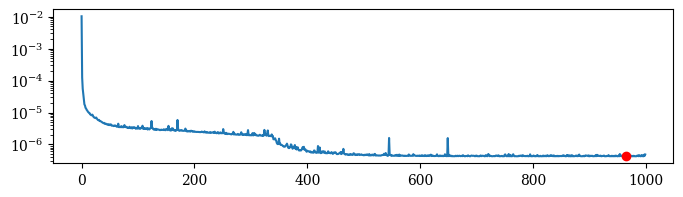

In [12]:
plt.figure(figsize=(8,2))
plt.plot(losses)
plt.yscale('log')
plt.scatter(best_epoch,losses[best_epoch], marker='o',c='red',zorder=2)
plt.show()

In [13]:
losses[best_epoch]

4.2471065533027693e-07